In [2]:
import pandas as pd
import os
from pathlib import Path
import sys
import time
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import meteostat
from tqdm import tqdm

In [3]:
#get list of cities
df_cities = pd.read_csv('/home/kieran/.cache/huggingface/hub/datasets--NUS-UAL--global-streetscapes/snapshots/7bd2e7697a3cb5f74ff05bd718babdb927f8b60d/cities688.csv')


In [3]:
df_cities.head()

,city,city_ascii,city_id,city_lat,city_lon,country,iso2,iso3,admin_name,capital,population,continent,img_count,koppen_geiger_zone,zone_description,timezone
0,Urasoe,Urasoe,1392003314,26.2458,127.7219,Japan,JP,JPN,Okinawa,NaN,115855.0,Asia,4942,Cfa,"Humid subtropical, no dry season",Asia/Tokyo
1,Sasagawa,Sasagawa,1392742964,37.2865,140.3727,Japan,JP,JPN,Fukushima,NaN,75128.0,Asia,9683,Cfa,"Humid subtropical, no dry season",Asia/Tokyo
2,Nha Trang,Nha Trang,1704497901,12.2495,109.1908,Vietnam,VN,VNM,Khánh Hòa,admin,392279.0,Asia,1295,Aw,Tropical wet and dry or savanna,Asia/Ho_Chi_Minh
3,Serrinha,Serrinha,1076832200,-11.6639,-39.0078,Brazil,BR,BRA,Bahia,NaN,83275.0,South America,126,Aw,Tropical wet and dry or savanna,America/Bahia
4,Shoreline,Shoreline,1840021118,47.7564,-122.3426,United States,US,USA,Washington,NaN,57027.0,North America,81189,Csb,"Mediterranean, warm summer",America/Los_Angeles


In [5]:
#define start date
start = datetime(2018,1,1)
end = datetime(2025,1,1)

In [6]:
#obtain loc of one city to test
Urasoe_row = df_cities.iloc[0]
print(Urasoe_row['city_lat'])
Urasoe = meteostat.Point(Urasoe_row['city_lat'],Urasoe_row['city_lon'],0) #altitude of 0 since idk


26.2458


In [7]:
data = meteostat.Daily(Urasoe,start,end)
data = data.fetch()


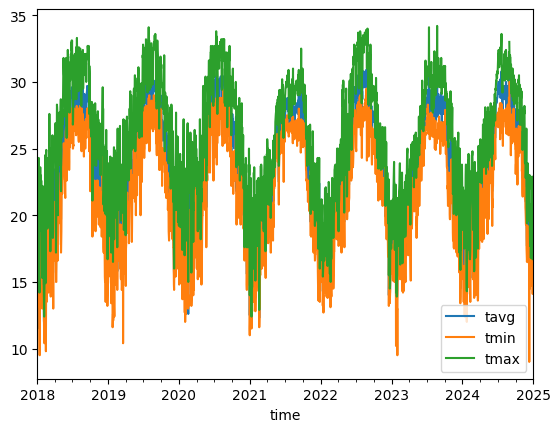

In [9]:
data.plot(y=['tavg', 'tmin', 'tmax'])
plt.show()

In [10]:
data.head()

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
time,,,,,,,,,,
2018-01-01,17.0,14.6,19.8,1.0,<NA>,<NA>,13.3,<NA>,1021.7,<NA>
2018-01-02,17.2,14.2,20.9,0.0,<NA>,<NA>,12.0,<NA>,1022.7,<NA>
2018-01-03,18.9,13.9,21.3,0.0,<NA>,<NA>,12.0,<NA>,1021.9,<NA>
2018-01-04,21.0,16.8,22.4,0.0,<NA>,<NA>,12.9,<NA>,1018.8,<NA>
2018-01-05,19.0,16.4,22.3,0.0,<NA>,<NA>,21.2,<NA>,1013.5,<NA>


In [ ]:
hot_days = data[data['tmax'] >= 34] #arbitrary max setting, could be based on stdev of location?

In [32]:
hot_days.head()

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
time,,,,,,,,,,
2019-07-29,30.3,28.8,34.1,0.0,<NA>,<NA>,15.3,<NA>,1011.1,<NA>
2022-08-30,30.9,28.1,34.0,2.0,<NA>,<NA>,9.1,<NA>,1008.6,<NA>
2023-07-13,30.5,27.4,34.1,0.0,<NA>,<NA>,22.7,<NA>,1010.6,<NA>
2023-08-24,30.2,26.1,34.2,0.0,<NA>,<NA>,15.0,<NA>,1009.1,<NA>


In [33]:
print(hot_days.index.name)

time


In [35]:
print(hot_days.loc['2019-07-29'])

tavg      30.3
tmin      28.8
tmax      34.1
prcp       0.0
snow      <NA>
wdir      <NA>
wspd      15.3
wpgt      <NA>
pres    1011.1
tsun      <NA>
Name: 2019-07-29 00:00:00, dtype: Float64


In [50]:
#now look at urasoe and see if it had coverage on those days?
hot_days_list = hot_days.index

In [54]:
print(hot_days_list.tolist())

[Timestamp('2019-07-29 00:00:00'), Timestamp('2022-08-30 00:00:00'), Timestamp('2023-07-13 00:00:00'), Timestamp('2023-08-24 00:00:00')]


In [4]:
df_streetscapes = pd.read_csv(
    "/home/kieran/.cache/huggingface/hub/datasets--NUS-UAL--global-streetscapes/snapshots/7bd2e7697a3cb5f74ff05bd718babdb927f8b60d/data/simplemaps.csv"
)

In [5]:
#add in another dataset to get the year of the image -> check for covid?
df_metadata = pd.read_csv('/home/kieran/.cache/huggingface/hub/datasets--NUS-UAL--global-streetscapes/snapshots/7bd2e7697a3cb5f74ff05bd718babdb927f8b60d/data/metadata_common_attributes.csv')
df_streetscapes = df_streetscapes.merge(df_metadata, on = ["uuid","source","orig_id"])
df_metadata = None

In [24]:
#analyze metadata to see if there is coverage days from Urasoe on that same day
df_streetscapes = df_streetscapes[df_streetscapes['city_ascii'] == 'Urasoe']

In [48]:
test = df_streetscapes['datetime_local'].iloc[0]
df_streetscapes['date_full_string'] = df_streetscapes['datetime_local'].str[:10]
df_streetscapes.head()
#print(test[:10])

,uuid,source,orig_id,city,city_ascii,city_id,city_lat,city_lon,country,iso2,...,width,height,heading,projection_type,hFoV,vFoV,sequence_index,sequence_id,sequence_img_count,date_full_string
0,d3cca4a7-7994-47ff-9749-7df8ca7228e3,Mapillary,412070930384924,Urasoe,Urasoe,1392003314,26.2458,127.7219,Japan,JP,...,4032.0,3024.0,167.199291,perspective,62.869449,49.255913,162,64fWKYwo1QbyUl0jZmuBOF,158,2021-11-03
1,33f474ab-496e-41a7-86a6-08fad8fe6638,Mapillary,897137344568478,Urasoe,Urasoe,1392003314,26.2458,127.7219,Japan,JP,...,4032.0,3024.0,22.705686,perspective,55.150854,42.778674,77,PEOixVS4MCXw9ZD7kd1uF2,230,2021-09-18
2,0da8bf8d-bf34-4d94-aa51-2a7a3c880f6b,Mapillary,266236242103987,Urasoe,Urasoe,1392003314,26.2458,127.7219,Japan,JP,...,4032.0,3024.0,38.106650,perspective,60.709414,47.424640,138,qc2h9ZIeNtUoDbBy6wdizl,206,2021-11-03
3,23c0aa2e-573b-4a3f-a65b-fb8f7349725b,Mapillary,646336503014104,Urasoe,Urasoe,1392003314,26.2458,127.7219,Japan,JP,...,4032.0,3024.0,55.659558,perspective,64.148411,50.347400,61,zH6VgUcYoibQ8907ytedxT,32,2021-09-18
4,4f47ba8e-8437-4213-9721-8336b02ea703,Mapillary,404485487755735,Urasoe,Urasoe,1392003314,26.2458,127.7219,Japan,JP,...,4032.0,3024.0,20.061962,perspective,55.150854,42.778674,142,PEOixVS4MCXw9ZD7kd1uF2,230,2021-09-18


In [61]:
print(type(df_streetscapes['datetime_local'].iloc[0]))

<class 'str'>


In [63]:
img_dates = pd.to_datetime(df_streetscapes['datetime_local'],format = 'ISO8601')

In [65]:
print(img_dates)

0      2021-11-03 16:01:23.605000+09:00
1      2021-09-18 11:44:28.690000+09:00
2      2021-11-03 10:33:46.609000+09:00
3      2021-09-18 10:49:02.615000+09:00
4      2021-09-18 11:45:33.766000+09:00
                     ...               
4937   2021-09-20 11:40:01.916000+09:00
4938   2021-11-03 11:23:06.577000+09:00
4939   2021-11-20 09:31:19.707000+09:00
4940   2021-09-21 10:42:15.094000+09:00
4941   2021-11-20 09:24:30.661000+09:00
Name: datetime_local, Length: 4942, dtype: datetime64[ns, UTC+09:00]


In [ ]:
#now check if any of the img data is from any of the hot days
intersecting_days = hot_days_list.intersection(img_dates.index)
print(intersecting_days)
#no intersections

Index([], dtype='object')


In [ ]:
#now define a function that does all of that automatically
def hotDayFinder(city_ascii,city_lat,city_lon,df_streetscapes):
    flag = 0
    start = datetime(2018,1,1)
    end = datetime(2025,1,1)
    print(city_ascii)
    city_point = meteostat.Point(city_lat,city_lon,0) #altitude of 0 since idk
    print(city_point)
    try:
        data = meteostat.Daily(city_point,start,end) #get data for stuff
    except:
        return 0,flag
    data = data.fetch()#ping a req for data
    hot_days = data[data['tmax'] >= 34] #arbitrary max setting, could be based on stdev of location? Also in C (assumed to be standard across all countries?)
    if len(hot_days) <1:
        flag = 1
        return 0,flag

    hot_days_list = hot_days.index
    df_city = df_streetscapes[df_streetscapes['city_ascii']== city_ascii]
    img_dates = pd.to_datetime(df_city['datetime_local'],format = 'ISO8601')
    intersecting_days = hot_days_list.intersection(img_dates.index)
    if len(intersecting_days) <1:
        flag = 1
        return 0,flag
    return intersecting_days,flag

In [7]:
df_streetscapes = pd.read_csv(
    "/home/kieran/.cache/huggingface/hub/datasets--NUS-UAL--global-streetscapes/snapshots/7bd2e7697a3cb5f74ff05bd718babdb927f8b60d/data/simplemaps.csv"
)

In [8]:
#add in another dataset to get the year of the image -> check for covid?
df_metadata = pd.read_csv('/home/kieran/.cache/huggingface/hub/datasets--NUS-UAL--global-streetscapes/snapshots/7bd2e7697a3cb5f74ff05bd718babdb927f8b60d/data/metadata_common_attributes.csv')
df_streetscapes = df_streetscapes.merge(df_metadata, on = ["uuid","source","orig_id"])
df_metadata = None

In [96]:
test,temp = hotDayFinder('Urasoe',Urasoe_row['city_lat'],Urasoe_row['city_lon'],df_streetscapes)


Urasoe


In [ ]:
unique_cities = df_streetscapes['city_ascii'].unique()
#unique_cities = unique_cities[10:20]
hot_days = []
hot_cities = []
for city in tqdm(unique_cities):
    city_lat = df_cities[df_cities['city_ascii'] == city]['city_lat']
    city_lon = df_cities[df_cities['city_ascii']== city]['city_lon']
    city_lat = city_lat.values[0]
    city_lon = city_lon.values[0]
    #print(city_lat)
    #print(city_lon)
    temp_output, flag = hotDayFinder(city,city_lat,city_lon,df_streetscapes)
    if flag ==0:
        hot_days.append(temp_output)
        hot_cities.append(city)


  0%|          | 0/684 [00:00<?, ?it/s]

Urasoe


  0%|          | 1/684 [00:00<04:33,  2.50it/s]

Sasagawa
Nha Trang


  0%|          | 3/684 [00:00<02:44,  4.13it/s]

...

Havana


 44%|████▎     | 298/684 [22:06<46:09,  7.18s/it]

San Marino


 44%|████▎     | 299/684 [22:09<38:59,  6.08s/it]

Rabat


In [ ]:
import pickle
filepath = 'test_day_list.pkl'
with open(filepath,'wb') as f:
    pickle.dump(hot_days,f)
filepath = 'test_city_list.pkl'
with open(filepath,'wb') as f:
    pickle.dump(hot_cities,f)



In [3]:
#import data from global streetscapes
df_person = pd.read_csv("/home/kieran/.cache/huggingface/hub/datasets--NUS-UAL--global-streetscapes/snapshots/7bd2e7697a3cb5f74ff05bd718babdb927f8b60d/data/instances.csv")
df_person = df_person[["uuid","source","orig_id","Person"]]

/tmp/ipykernel_68378/96912544.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_streetscapes = pd.read_csv(


In [5]:
# load contextual information
df_contextual = pd.read_csv("/home/kieran/.cache/huggingface/hub/datasets--NUS-UAL--global-streetscapes/snapshots/7bd2e7697a3cb5f74ff05bd718babdb927f8b60d/data/contextual.csv")

/tmp/ipykernel_68378/3841991617.py:2: DtypeWarning: Columns (5,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_contextual = pd.read_csv("/home/kieran/.cache/huggingface/hub/datasets--NUS-UAL--global-streetscapes/snapshots/7bd2e7697a3cb5f74ff05bd718babdb927f8b60d/data/contextual.csv")


In [6]:
#merge contextual data with original data
df_streetscapes = df_streetscapes.merge(df_contextual,on = ["uuid","source","orig_id"])
df_contextual = None

In [7]:
#merge with number of people
df_streetscapes = df_streetscapes.merge(df_person, on =["uuid","source","orig_id"])
df_person = None

/tmp/ipykernel_68378/1796699445.py:2: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  df_streetscapes = df_streetscapes.merge(df_person, on =["uuid","source","orig_id"])


In [ ]:
df_segmentation = pd.read_csv("/home/kieran/.cache/huggingface/hub/datasets--NUS-UAL--global-streetscapes/snapshots/7bd2e7697a3cb5f74ff05bd718babdb927f8b60d/data/segmentation.csv")
#only keep the useful stuff/necessary stuff
df_segmentation = df_segmentation[["uuid","source","orig_id","Person",'green_view_index','sky_view_index','Total','Vegetation','Water','Sky']]

In [ ]:
df_streetscapes = df_streetscapes.merge(df_segmentation,on = ['uuid','source','orig_id'])
df_segmentation = None

In [ ]:
#merge with ghsl (global human settlement layer) data
df_ghsl = pd.read_csv('/home/kieran/.cache/huggingface/hub/datasets--NUS-UAL--global-streetscapes/snapshots/7bd2e7697a3cb5f74ff05bd718babdb927f8b60d/data/ghsl.csv')
df_streetscapes = df_streetscapes.merge(df_ghsl, on =["uuid","source","orig_id"])
df_ghsl = None

In [ ]:
#add in season and koppen climate to dataset?
df_season = pd.read_csv('/home/kieran/.cache/huggingface/hub/datasets--NUS-UAL--global-streetscapes/snapshots/7bd2e7697a3cb5f74ff05bd718babdb927f8b60d/data/season.csv')
df_streetscapes = df_streetscapes.merge(df_season, on =["uuid","source","orig_id"])
df_season = None

In [ ]:
df_climate = pd.read_csv('/home/kieran/.cache/huggingface/hub/datasets--NUS-UAL--global-streetscapes/snapshots/7bd2e7697a3cb5f74ff05bd718babdb927f8b60d/data/climate.csv')
df_streetscapes = df_streetscapes.merge(df_climate, on =["uuid","source","orig_id"])
df_climate = None

In [ ]:
df_osm = pd.read_csv('/home/kieran/.cache/huggingface/hub/datasets--NUS-UAL--global-streetscapes/snapshots/7bd2e7697a3cb5f74ff05bd718babdb927f8b60d/data/osm.csv')
df_streetscapes = df_streetscapes.merge(df_osm, on = ["uuid","source","orig_id"])
df_osm = None

In [ ]:
#obtain weather data for each city 